In [1]:
import os
import gc
import glob
import json
#import h5py
import numpy as np
import pickle
import pandas as pd
#from IPython.display import Audio, display
from collections import Counter, defaultdict
from pynwb import NWBHDF5IO
from datetime import datetime
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, silhouette_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cosine, euclidean
from scipy import stats
import scipy.signal

In [2]:
from extract_features import extractHG, stackFeatures, downsampleLabels
from brain_audio_decoder import BrainAudioDecoder
from custom_decoder import CustomBrainAudioDecoder
from brain_audio_decoder_viz import BrainAudioDecoderViz
from acoustic_change_detector import AcousticChangeDetector
from phoneme_validator import PhonemeValidator
from phonetic_dictionary import PhoneticDictionary
#from feature_vizualizer import PhonemeFeatureVisualizer
from markov_phoneme_model import MarkovPhonemeModel
from extract_features import extractHG, downsampleLabels, extractMelSpecs
from pipeline import UnifiedPhonemePipeline
from config import BIDS_PATH, OUTPUT_PATH, RESULTS_PATH, DUTCH_30_PATH, DUTCH_10_PATH, get_dataset_paths

Running from clean repo, using data from: C:\mozg\code\SingleWordProductionDutch


In [3]:
from dutch_30_pipeline import Dutch30Pipeline
from dutch_30_feature_extractor import Dutch30FeatureExtractor
from phoneme_detection_diagnostic import Dutch30PhonemeDetectionDiagnostic 
from dataset_config import Dutch30Config

from transformers import Wav2Vec2Model, Wav2Vec2Processor
import torch

In [4]:
# plt.ion()

In [5]:
dutch30_dir = DUTCH_30_PATH

# List all .npy files for one patient
patient_files = glob.glob(os.path.join(dutch30_dir, 'P01*.npy'))

In [6]:
# Check we're using the right paths
print(f"BIDS path: {BIDS_PATH}")
print(f"Output path: {OUTPUT_PATH}")
print(f"Results path: {RESULTS_PATH}")
# Define paths
path_bids = BIDS_PATH # './SingleWordProductionDutch-iBIDS'  # Path to the BIDS dataset
path_output = OUTPUT_PATH #'./features'  # Path to save extracted features
path_results = RESULTS_PATH #'./results'  # Path to save results
paths_30 = get_dataset_paths('dutch30')

BIDS path: C:\mozg\code\SingleWordProductionDutch\Dutch_10patients
Output path: C:\mozg\code\SingleWordProductionDutch\features
Results path: C:\mozg\code\SingleWordProductionDutch\results


In [7]:
# Create config
# config = Dutch30Config()

# # Pass config to both extractor and pipeline
# extractor = Dutch30FeatureExtractor(config=config)

# pipeline = Dutch30Pipeline(
#     dutch30_extractor=extractor,
#     config=config, 
#     debug_mode=True,
#     pca_components=100,
#     feature_extraction_method='high_gamma', 
    
# )

# # Debug a specific patient
# pipeline.debug_sentence_parsing('sub-p21', max_samples=3)
# print([attr for attr in dir(pipeline_debug) if 'detect' in attr.lower()])

In [8]:
# Load pre-trained wav2vec model
# processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
# model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base", use_safetensors=True)
# config = Dutch30Config()
# extractor = Dutch30FeatureExtractor()

In [9]:
# #check where method is used
# import os

# search_term = "standardize_channels"
# project_path = r"D:\Documents\UM DACS\bachelor\UM DACS\bachelor\mozg\code\SingleWordProductionDutch_step2"

# for filename in os.listdir(project_path):
#     if filename.endswith('.py'):
#         filepath = os.path.join(project_path, filename)
#         with open(filepath, 'r', encoding='utf-8') as f:
#             lines = f.readlines()
#             for line_num, line in enumerate(lines, 1):
#                 if search_term in line and 'def ' not in line and not line.strip().startswith('#'):
#                     print(f"{filename}:{line_num}: {line.strip()}")

In [10]:
extractor = Dutch30FeatureExtractor()

pipeline = Dutch30Pipeline(
        dutch30_extractor=extractor,
        debug_mode=False,
        pca_components= None, #100,
        feature_extraction_method = 'high_gamma',# 'high_gamma', #'band_powers', #'band_power_hjorth', # 'hjorth', #'band_powers',# 'hjorth', #'high_gamma', # 'band_powers', # 'band_power_hjorth'
        use_rms_boundaries=False,   
        use_multifeature=False,
        use_wav2vec=True,
        subtract_baseline=False,
        #baseline_method = 'band_powers' #'feature_matched', 'band_powers', 'raw'
    )

sample_fraction = 1
patient_range = (1,30)

# Try to load checkpoint
print(f"Attempting to load checkpoint (sample_fraction={sample_fraction})...")
    
if pipeline.try_load_checkpoint(sample_fraction=sample_fraction):
    print(f"Checkpoint loaded successfully!")
    print(f"  Train samples: {len(pipeline.train.get('features', []))}")
    print(f"  Test samples: {len(pipeline.test.get('features', []))}")
    
else: # No checkpoint found - run all steps
    print(f"No checkpoint found. Running pipeline steps...")
    
    print(f"\n  Step 1: Loading data (patients {patient_range})...")

    # Load pre-trained wav2vec model
    processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
    model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base", use_safetensors=True)
    config = Dutch30Config()
    extractor = Dutch30FeatureExtractor()
    pipeline.step1_load_dutch30_data(patient_range=(1,30))
    pipeline.split_result = None
    pipeline.step2_split_by_instances();
    pipeline.step3_load_channel_exclusions('channel_exclusions.json')
    pipeline.step4_custom_detector()
    pipeline.step5_accumulate_data_dutch30()
    pipeline.step5b_normalize_segment_lengths(augment=True)
    pipeline.dutch30_step6_resolve_unknowns()
    pipeline.checkpoint_after_step6(sample_fraction=sample_fraction)
    pipeline.step7_filter_unknowns(unknown_keep_ratio=0.0025);

    print(f"  Train samples: {len(pipeline.train.get('features', []))}")
    print(f"  Test samples: {len(pipeline.test.get('features', []))}")   

Dutch30FeatureExtractor: Dutch30FeatureExtractor initialized:
Dutch30FeatureExtractor:   Data dir: C:\mozg\code\SingleWordProductionDutch\Dutch_30patients\raw
Dutch30FeatureExtractor:   Results dir: C:\mozg\code\SingleWordProductionDutch\results\dutch30
Dutch30FeatureExtractor:   Sampling rate: 1024 Hz
CustomBrainAudioDecoder: Initializing CustomBrainAudioDecoder with debug_mode=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 729 sentence-level entries
PhoneticDictionary: Mismatch (after merge): ''s morgens': 2 words vs 1 phoneme groups
PhoneticDictionary: Added 1997 individual word entries
PhoneticDictionary: Skipped 1 sentences with unresolvable mismatches
UnifiedPhonemePipeline: Pipeline initialized: high_gamma, PCA=None, groups=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 729 sentence-level entries
PhoneticDictionary: Mismatch (after merge): ''s morgens': 2 words vs 1 phoneme groups
PhoneticDictionary: A

C:\ProgramData\anaconda3\Lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


AcousticChangeDetector: Wav2vec model initialized successfully
Attempting to load checkpoint (sample_fraction=1)...
UnifiedPhonemePipeline: Loading checkpoint: pipeline_high_gamma_pcaNone_sample100_after_step6_20260201_170025.pkl
UnifiedPhonemePipeline: Checkpoint loaded: train=238960, test=8691 samples
Checkpoint loaded successfully!
  Train samples: 238960
  Test samples: 8691


In [11]:
# diag = Dutch30PhonemeDetectionDiagnostic(pipeline)
# diag.visualize_word_analysis('P01', word_name = 'vogelkooitje', save_path='p21_word5.png')

In [12]:
# #diag.visualize_multifeature_analysis('P01', word_index=50)
# diag.visualize_rms_boundaries('P01',  word_name = 'vogelkooitje')

In [13]:
# # Quick check first 10 words
# diag.batch_diagnostic('sub-p21', num_samples=5)

In [14]:
# Check if pipeline has any partial results
if hasattr(pipeline, 'detector'):
    print("Detector exists")
    
# Check if there's any train data accumulating
if hasattr(pipeline, 'train') and pipeline.train is not None:
    print(f"Train data so far: {len(pipeline.train.get('phoneme_labels', []))} phonemes")

Detector exists
Train data so far: 238960 phonemes


In [15]:
def test_classifiers_for_markov_v2(pipeline, patient_id='P23'):
    """
    Test classifiers with proper handling of class imbalance.
    
    Improvements:
    1. Use stratified sampling to balance classes
    2. Calculate baseline from majority class (not uniform)
    3. Report balanced accuracy
    4. Filter rare classes
    """
    import numpy as np
    from collections import Counter
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
    from sklearn.svm import LinearSVC
    from sklearn.linear_model import LogisticRegression
    from sklearn.neural_network import MLPClassifier
    from sklearn.preprocessing import StandardScaler, LabelEncoder
    from sklearn.calibration import CalibratedClassifierCV
    from sklearn.metrics import balanced_accuracy_score
    
    try:
        from xgboost import XGBClassifier
        has_xgb = True
    except ImportError:
        has_xgb = False
        print("XGBoost not installed, skipping")
    
    try:
        from lightgbm import LGBMClassifier
        has_lgbm = True
    except ImportError:
        has_lgbm = False
        print("LightGBM not installed, skipping")
    
    print("="*70)
    print(f"CLASSIFIER COMPARISON FOR {patient_id} (v2 - balanced)")
    print("="*70)
    
    # Get data for this patient
    train_mask = [p == patient_id for p in pipeline.train['phoneme_participant_ids']]
    test_mask = [p == patient_id for p in pipeline.test['phoneme_participant_ids']]
    
    train_feat = [pipeline.train['features'][i] for i, m in enumerate(train_mask) if m]
    train_labels = [pipeline.train['phoneme_labels'][i] for i, m in enumerate(train_mask) if m]
    test_feat = [pipeline.test['features'][i] for i, m in enumerate(test_mask) if m]
    test_labels = [pipeline.test['phoneme_labels'][i] for i, m in enumerate(test_mask) if m]
    
    # Prepare features
    X_train = np.array([f.mean(axis=0) if f.ndim > 1 else f for f in train_feat])
    X_test = np.array([f.mean(axis=0) if f.ndim > 1 else f for f in test_feat])
    y_train = np.array(train_labels)
    y_test = np.array(test_labels)
    
    # Filter unknown labels
    train_valid = y_train != '?'
    test_valid = y_test != '?'
    X_train = X_train[train_valid]
    y_train = y_train[train_valid]
    X_test = X_test[test_valid]
    y_test = y_test[test_valid]
    
    # Filter rare classes (need at least 3 in train AND 1 in test)
    train_counts = Counter(y_train)
    test_counts = Counter(y_test)
    
    valid_classes = [c for c, count in train_counts.items() 
                     if count >= 3 and c in test_counts]
    
    train_keep = np.isin(y_train, valid_classes)
    test_keep = np.isin(y_test, valid_classes)
    
    X_train = X_train[train_keep]
    y_train = y_train[train_keep]
    X_test = X_test[test_keep]
    y_test = y_test[test_keep]
    
    print(f"Train: {len(X_train)}, Test: {len(X_test)}")
    print(f"Classes: {len(valid_classes)}")
    
    # Show class distribution
    train_counts = Counter(y_train)
    test_counts = Counter(y_test)
    
    print(f"\nTop 5 classes in train: {train_counts.most_common(5)}")
    print(f"Top 5 classes in test: {test_counts.most_common(5)}")
    
    # Calculate baselines
    n_classes = len(valid_classes)
    random_baseline = 1 / n_classes
    majority_class = train_counts.most_common(1)[0][0]
    majority_baseline = test_counts[majority_class] / len(y_test)
    
    print(f"\nBaselines:")
    print(f"  Random: {random_baseline:.4f}")
    print(f"  Majority ('{majority_class}'): {majority_baseline:.4f}")
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Encode labels
    le = LabelEncoder()
    le.fit(valid_classes)
    y_train_enc = le.transform(y_train)
    y_test_enc = le.transform(y_test)
    
    # Define classifiers
    classifiers = {
        'RF_balanced': RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            min_samples_leaf=2,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ),
        'RF_balanced_subsample': RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            min_samples_leaf=3,
            max_features='sqrt',
            class_weight='balanced_subsample',
            random_state=42,
            n_jobs=-1
        ),
        'GradientBoosting': GradientBoostingClassifier(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            random_state=42
        ),
        'LogisticRegression': LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42,
            n_jobs=-1
        ),
        'MLP_small': MLPClassifier(
            hidden_layer_sizes=(128, 64),
            max_iter=500,
            early_stopping=True,
            random_state=42
        ),
        'MLP_large': MLPClassifier(
            hidden_layer_sizes=(256, 128, 64),
            max_iter=500,
            early_stopping=True,
            random_state=42
        ),
    }
    
    if has_xgb:
        # Compute class weights for XGBoost
        class_counts = np.bincount(y_train_enc)
        class_weights = len(y_train_enc) / (len(class_counts) * class_counts)
        sample_weights = class_weights[y_train_enc]
        
        classifiers['XGBoost'] = {
            'clf': XGBClassifier(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.1,
                random_state=42,
                n_jobs=-1,
                eval_metric='mlogloss'
            ),
            'sample_weight': sample_weights
        }
    
    if has_lgbm:
        classifiers['LightGBM'] = LGBMClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )
    
    # Test each classifier
    results = {}
    
    for name, clf_config in classifiers.items():
        print(f"\nTesting {name}...")
        
        try:
            # Handle XGBoost with sample weights
            if isinstance(clf_config, dict):
                clf = clf_config['clf']
                clf.fit(X_train_scaled, y_train_enc, 
                       sample_weight=clf_config['sample_weight'])
            else:
                clf = clf_config
                clf.fit(X_train_scaled, y_train_enc)
            
            y_pred_enc = clf.predict(X_test_scaled)
            y_pred = le.inverse_transform(y_pred_enc)
            
            # Standard accuracy
            accuracy = np.mean(y_pred == y_test)
            
            # Balanced accuracy (average of per-class recall)
            bal_accuracy = balanced_accuracy_score(y_test, y_pred)
            
            # Lift over baselines
            lift_random = accuracy / random_baseline
            lift_majority = accuracy / majority_baseline
            lift_balanced = bal_accuracy / random_baseline
            
            # Prediction diversity
            pred_counts = Counter(y_pred)
            n_unique_preds = len(pred_counts)
            top_pred, top_count = pred_counts.most_common(1)[0]
            top_pct = 100 * top_count / len(y_pred)
            
            results[name] = {
                'accuracy': accuracy,
                'balanced_accuracy': bal_accuracy,
                'lift_random': lift_random,
                'lift_majority': lift_majority,
                'lift_balanced': lift_balanced,
                'n_unique_preds': n_unique_preds,
                'top_pred': top_pred,
                'top_pct': top_pct,
                'predictions': y_pred
            }
            
            print(f"  Accuracy: {accuracy:.4f} (lift vs random: {lift_random:.2f}x)")
            print(f"  Balanced Accuracy: {bal_accuracy:.4f} (lift: {lift_balanced:.2f}x)")
            print(f"  Unique predictions: {n_unique_preds}/{n_classes}")
            print(f"  Top prediction: '{top_pred}' = {top_pct:.1f}%")
            
        except Exception as e:
            print(f"  FAILED: {e}")
            import traceback
            traceback.print_exc()
            results[name] = {'error': str(e)}
    
    # Summary table
    print("\n" + "="*70)
    print("SUMMARY (sorted by Balanced Accuracy)")
    print("="*70)
    
    print(f"{'Classifier':<22} {'Acc':<8} {'BalAcc':<8} {'Lift':<8} {'Unique':<8} {'Top%':<8}")
    print("-"*70)
    
    sorted_results = sorted(
        [(k, v) for k, v in results.items() if 'accuracy' in v],
        key=lambda x: x[1]['balanced_accuracy'],
        reverse=True
    )
    
    for name, r in sorted_results:
        print(f"{name:<22} {r['accuracy']:<8.4f} {r['balanced_accuracy']:<8.4f} "
              f"{r['lift_balanced']:<8.2f}x {r['n_unique_preds']:<8} {r['top_pct']:<8.1f}%")
    
    # Best classifier
    best_name, best_result = sorted_results[0]
    print(f"\nBest by Balanced Accuracy: {best_name}")
    print(f"  Accuracy: {best_result['accuracy']:.4f}")
    print(f"  Balanced Accuracy: {best_result['balanced_accuracy']:.4f}")
    print(f"  Predicts {best_result['n_unique_preds']}/{n_classes} classes")
    
    return results, scaler, le


# Run the comparison
classifier_results, scaler, label_encoder = test_classifiers_for_markov_v2(
    pipeline, 
    patient_id='P26'
)

XGBoost not installed, skipping
LightGBM not installed, skipping
CLASSIFIER COMPARISON FOR P26 (v2 - balanced)
Train: 13253, Test: 575
Classes: 39

Top 5 classes in train: [(np.str_('ə'), 393), (np.str_('d'), 363), (np.str_('i'), 362), (np.str_('n'), 362), (np.str_('a'), 361)]
Top 5 classes in test: [(np.str_('ə'), 70), (np.str_('n'), 44), (np.str_('t'), 43), (np.str_('k'), 28), (np.str_('s'), 27)]

Baselines:
  Random: 0.0256
  Majority ('ə'): 0.1217

Testing RF_balanced...
  Accuracy: 0.0678 (lift vs random: 2.65x)
  Balanced Accuracy: 0.0275 (lift: 1.07x)
  Unique predictions: 33/39
  Top prediction: 'ə' = 22.3%

Testing RF_balanced_subsample...
  Accuracy: 0.0626 (lift vs random: 2.44x)
  Balanced Accuracy: 0.0335 (lift: 1.31x)
  Unique predictions: 36/39
  Top prediction: 'ə' = 12.9%

Testing GradientBoosting...
  Accuracy: 0.0591 (lift vs random: 2.31x)
  Balanced Accuracy: 0.0238 (lift: 0.93x)
  Unique predictions: 32/39
  Top prediction: 'ə' = 32.7%

Testing LogisticRegression.

In [16]:
def train_simple_classifiers(pipeline, save_path=None, fast_mode=True):
    """
    Test multiple simple classifiers per patient.
    
    Args:
        pipeline: Pipeline with train/test data
        save_path: Optional path to save heatmap
        fast_mode: If True, skip slow classifiers (SVM, MLP, deep trees)
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import os
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
    from sklearn.naive_bayes import GaussianNB
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.svm import SVC
    from sklearn.neural_network import MLPClassifier
    from sklearn.preprocessing import StandardScaler, LabelEncoder
    from sklearn.metrics import accuracy_score
    
    # Get pipeline parameters for titles
    pca_components = getattr(pipeline, 'pca_components', None)
    feature_method = getattr(pipeline, 'feature_extraction_method', 'unknown')
    subtract_baseline = getattr(pipeline, 'subtract_baseline_flag', 'unknown')
    
    title_suffix = f"PCA={pca_components}, Features={feature_method}, Baseline={subtract_baseline}"
    
    if fast_mode:
        # Fast classifiers only
        classifiers = {
            'RandomForest_Simple': RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1),
            'RandomForest_Medium': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
            'ExtraTrees': ExtraTreesClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
            'GaussianNB': GaussianNB(),
            'KNN_30': KNeighborsClassifier(n_neighbors=30, n_jobs=-1),
            'LogisticRegression': LogisticRegression(max_iter=500, random_state=42, n_jobs=-1),
            'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=42),
        }
        print("Running in FAST MODE (skipping SVM, MLP, deep trees)")
    else:
        # Full set including slow ones
        classifiers = {
            'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
            'RandomForest_Simple': RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1),
            'RandomForest_Deep': RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42, n_jobs=-1),
            'RandomForest_Large': RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=2, random_state=42, n_jobs=-1),
            'ExtraTrees': ExtraTreesClassifier(n_estimators=100, max_depth=None, random_state=42, n_jobs=-1),
            'GradientBoosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
            'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
            'SVM_RBF': SVC(kernel='rbf', C=1.0, random_state=42),  # SLOW
            'SVM_Linear': SVC(kernel='linear', C=1.0, random_state=42),  # SLOW
            'MLP_Small': MLPClassifier(hidden_layer_sizes=(64,), max_iter=500, random_state=42),  # SLOW
            'MLP_Medium': MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42),  # SLOW
            'GaussianNB': GaussianNB(),
            'KNN_30': KNeighborsClassifier(n_neighbors=30, n_jobs=-1),
            'KNN_35': KNeighborsClassifier(n_neighbors=35, n_jobs=-1),
            'KNN_50': KNeighborsClassifier(n_neighbors=50, n_jobs=-1),
        }
    
    # Optional imports
    try:
        from xgboost import XGBClassifier
        classifiers['XGBoost'] = XGBClassifier(
            n_estimators=100, 
            max_depth=5, 
            learning_rate=0.1,
            random_state=42,
            use_label_encoder=False,
            eval_metric='mlogloss',
            verbosity=0,
            n_jobs=-1
        )
    except ImportError:
        pass
    
    try:
        from lightgbm import LGBMClassifier
        classifiers['LightGBM'] = LGBMClassifier(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            random_state=42,
            verbose=-1,
            n_jobs=-1
        )
    except ImportError:
        pass
    
    results = {}
    patients = sorted(set(pipeline.train['phoneme_participant_ids']))
    
    for idx, pid in enumerate(patients):
        print(f"Processing {pid} ({idx+1}/{len(patients)})...", end=" ")
        
        # Filter data
        train_mask = [p == pid for p in pipeline.train['phoneme_participant_ids']]
        test_mask = [p == pid for p in pipeline.test['phoneme_participant_ids']]
        
        train_feat = [pipeline.train['features'][i] for i, m in enumerate(train_mask) if m]
        train_labels = [pipeline.train['phoneme_labels'][i] for i, m in enumerate(train_mask) if m]
        test_feat = [pipeline.test['features'][i] for i, m in enumerate(test_mask) if m]
        test_labels = [pipeline.test['phoneme_labels'][i] for i, m in enumerate(test_mask) if m]
        
        if len(train_feat) < 10 or len(test_feat) < 5:
            print(f"Skipped (insufficient data)")
            continue
        
        # Flatten features
        X_train = np.array([np.mean(f, axis=0) if f.ndim > 1 else f for f in train_feat])
        X_test = np.array([np.mean(f, axis=0) if f.ndim > 1 else f for f in test_feat])
        
        # Check for NaN/Inf
        valid_train = ~(np.isnan(X_train).any(axis=1) | np.isinf(X_train).any(axis=1))
        valid_test = ~(np.isnan(X_test).any(axis=1) | np.isinf(X_test).any(axis=1))
        
        X_train = X_train[valid_train]
        y_train = [train_labels[i] for i in range(len(train_labels)) if valid_train[i]]
        X_test = X_test[valid_test]
        y_test = [test_labels[i] for i in range(len(test_labels)) if valid_test[i]]
        
        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Filter test labels to only those seen in training
        train_labels_set = set(y_train)
        valid_test_idx = [i for i, label in enumerate(y_test) if label in train_labels_set]
        
        if len(valid_test_idx) < len(y_test):
            X_test_scaled = X_test_scaled[valid_test_idx]
            y_test = [y_test[i] for i in valid_test_idx]
        
        if len(y_test) < 5:
            print("Skipped (too few test samples)")
            continue    
        
        label_encoder = LabelEncoder()
        y_train_encoded = label_encoder.fit_transform(y_train)
        y_test_encoded = label_encoder.transform(y_test)

        # Test each classifier
        results[pid] = {}
        
        for name, clf in classifiers.items():
            try:
                if 'XGBoost' in name or 'LightGBM' in name:
                    clf.fit(np.asarray(X_train_scaled, dtype=np.float32), y_train_encoded)
                    preds_encoded = clf.predict(np.asarray(X_test_scaled, dtype=np.float32))
                    preds = label_encoder.inverse_transform(preds_encoded)
                else:
                    clf.fit(X_train_scaled, y_train)
                    preds = clf.predict(X_test_scaled)
                
                acc = accuracy_score(y_test, preds)
                results[pid][name] = acc
                
            except Exception as e:
                results[pid][name] = 0.0
        
        best_acc = max(results[pid].values())
        print(f"Best: {best_acc:.3f}")
    
    # Create results DataFrame
    all_patients = sorted(results.keys())
    all_classifiers = list(classifiers.keys())
    
    data = []
    for clf_name in all_classifiers:
        row = [results.get(pid, {}).get(clf_name, np.nan) for pid in all_patients]
        data.append(row)
    
    df = pd.DataFrame(data, index=all_classifiers, columns=all_patients)
    df['Mean'] = df.mean(axis=1)
    df_sorted = df.sort_values('Mean', ascending=False)
    
    print("\n" + "="*90)
    print(f"RANKED BY MEAN ACCURACY - {title_suffix}")
    print("="*90)
    print(df_sorted.to_string())
    
    # Heatmap
    fig, ax = plt.subplots(figsize=(12, max(6, len(all_classifiers) * 0.4)))
    df_heatmap = df.drop(columns=['Mean'])
    
    im = ax.imshow(df_heatmap.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=0.3)
    
    ax.set_xticks(range(len(all_patients)))
    ax.set_xticklabels(all_patients, fontsize=10)
    ax.set_yticks(range(len(all_classifiers)))
    ax.set_yticklabels(all_classifiers, fontsize=9)
    
    for i in range(len(all_classifiers)):
        for j in range(len(all_patients)):
            val = df_heatmap.values[i, j]
            if not np.isnan(val):
                color = 'white' if val > 0.15 else 'black'
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Accuracy', fontsize=10)
    
    ax.set_xlabel('Patient', fontsize=11)
    ax.set_ylabel('Classifier', fontsize=11)
    ax.set_title(f'Classifier Accuracy by Patient\n{title_suffix}', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        os.makedirs(save_path, exist_ok=True)
        filename = f"classifiers_heatmap_pca{pca_components}_{feature_method}_baseline{subtract_baseline}.png"
        filepath = os.path.join(save_path, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"\nHeatmap saved to: {filepath}")
    
    plt.show()
    
    return results, df_sorted

Processing P01 (1/27)... 

C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

Best: 0.103
Best: 0.131P02 (2/27)... 
Best: 0.091P03 (3/27)... 
Best: 0.127P04 (4/27)... 
Best: 0.140P06 (5/27)... 
Best: 0.081P07 (6/27)... 
Best: 0.082P08 (7/27)... 
Best: 0.123P09 (8/27)... 
Best: 0.122P10 (9/27)... 
Best: 0.121P11 (10/27)... 
Best: 0.112P12 (11/27)... 
Best: 0.122P13 (12/27)... 
Best: 0.105P14 (13/27)... 
Best: 0.094P15 (14/27)... 
Best: 0.151P16 (15/27)... 
Best: 0.088P17 (16/27)... 
Processing P20 (17/27)... 

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Best: 0.091
Best: 0.113P21 (18/27)... 
Best: 0.113P22 (19/27)... 
Best: 0.105P23 (20/27)... 
Best: 0.111P24 (21/27)... 
Best: 0.121P25 (22/27)... 
Best: 0.092P26 (23/27)... 
Best: 0.126P27 (24/27)... 
Best: 0.085P28 (25/27)... 
Best: 0.107P29 (26/27)... 
Best: 0.108P30 (27/27)... 

RANKED BY MEAN ACCURACY - PCA=None, Features=high_gamma, Baseline=False
                          P01       P02       P03       P04       P06       P07       P08       P09       P10       P11    P12       P13       P14       P15       P16    P17       P20       P21       P22       P23       P24       P25       P26       P27       P28       P29       P30      Mean
ExtraTrees           0.046729  0.130769  0.090909  0.095238  0.096774  0.080645  0.063636  0.122807  0.094595  0.088710  0.112  0.086331  0.072581  0.094488  0.107527  0.088  0.082645  0.112648  0.108635  0.105099  0.111441  0.120721  0.091854  0.095385  0.084507  0.106632  0.108449  0.096287
SVM_RBF              0.037383  0.069231  0.045455  0.1269

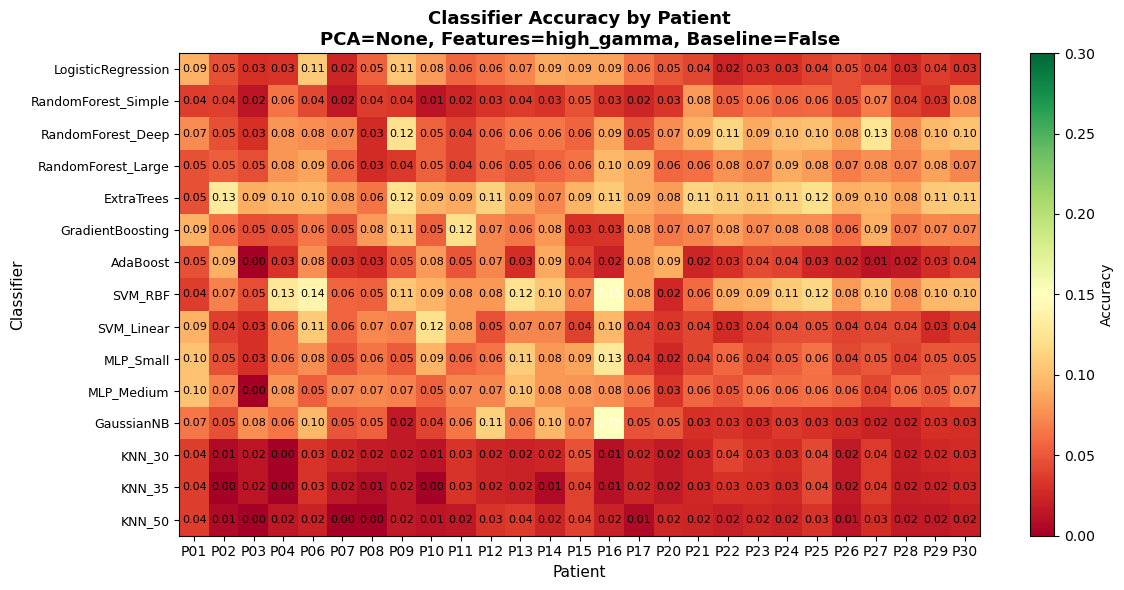

In [17]:
results, df = train_simple_classifiers(pipeline, fast_mode=False)

In [19]:
def check_pipeline_channels(pipeline, patient_id=None):
    """
    Check channel information at different stages of the pipeline.
    
    Args:
        pipeline: Dutch30Pipeline after loading data
        patient_id: Specific patient to check (default: first available)
    """
    import numpy as np
    
    print("="*70)
    print("CHANNEL ANALYSIS ACROSS PIPELINE STAGES")
    print("="*70)
    
    # Get patient ID
    if patient_id is None:
        patient_id = list(pipeline.split_result['word_segments_dict'].keys())[0]
    
    print(f"\nPatient: {patient_id}")
    print("-"*70)
    
    # Stage 1: Raw data in word_segments_dict
    print("\n1. RAW DATA (word_segments_dict):")
    word_segments_dict = pipeline.split_result['word_segments_dict']
    
    if patient_id in word_segments_dict:
        words_data = word_segments_dict[patient_id]['words']
        first_word = list(words_data.keys())[0]
        eeg_segment = words_data[first_word]['instances'][0]['eeg_segment']
        
        print(f"   EEG shape: {eeg_segment.shape}")
        print(f"   Total channels: {eeg_segment.shape[1]}")
        print(f"   Samples in segment: {eeg_segment.shape[0]}")
    
    # Stage 2: Check if pipeline has channel info stored
    print("\n2. PIPELINE CONFIGURATION:")
    if hasattr(pipeline, 'config'):
        config = pipeline.config
        print(f"   EEG sample rate: {config.eeg_sr} Hz")
        if hasattr(config, 'n_channels'):
            print(f"   Config n_channels: {config.n_channels}")
        if hasattr(config, 'channel_names'):
            print(f"   Channel names available: {config.channel_names is not None}")
    
    # Stage 3: Check train data features
    print("\n3. EXTRACTED FEATURES (pipeline.train):")
    if hasattr(pipeline, 'train') and pipeline.train is not None:
        train_data = pipeline.train
        
        # Find features for this patient
        patient_mask = [pid == patient_id for pid in train_data['phoneme_participant_ids']]
        patient_indices = np.where(patient_mask)[0]
        
        if len(patient_indices) > 0:
            sample_feat = train_data['features'][patient_indices[0]]
            print(f"   Feature shape: {sample_feat.shape}")
            print(f"   Number of samples for {patient_id}: {len(patient_indices)}")
            
            if sample_feat.ndim == 1:
                print(f"   Features are 1D (already aggregated): {sample_feat.shape[0]} features")
            elif sample_feat.ndim == 2:
                print(f"   Features are 2D: {sample_feat.shape[0]} time x {sample_feat.shape[1]} channels/features")
        else:
            print(f"   No training samples found for {patient_id}")
    
    # Stage 4: Check if there's electrode/channel metadata
    print("\n4. ELECTRODE METADATA:")
    if hasattr(pipeline, 'electrode_info'):
        print(f"   Electrode info available: {pipeline.electrode_info is not None}")
    
    # Check in split_result
    if 'electrode_info' in pipeline.split_result:
        electrode_info = pipeline.split_result['electrode_info']
        if patient_id in electrode_info:
            patient_electrodes = electrode_info[patient_id]
            print(f"   Electrodes for {patient_id}: {len(patient_electrodes)}")
            if isinstance(patient_electrodes, dict):
                print(f"   Electrode keys: {list(patient_electrodes.keys())[:5]}...")
    
    return {
        'patient_id': patient_id,
        'raw_channels': eeg_segment.shape[1] if 'eeg_segment' in dir() else None,
    }


def check_preprocessor_channels(opt):
    """
    Check channel selection in RawPreprocessor at different steps.
    
    Args:
        opt: RawPreprocessor instance after running some steps
    """
    print("="*70)
    print(f"RAWPREPROCESSOR CHANNEL ANALYSIS - {opt.patient_id}")
    print("="*70)
    
    # Original channels
    print(f"\n1. ORIGINAL DATA:")
    print(f"   Total channels available: {opt.n_channels_total}")
    
    # After channel selection
    if hasattr(opt, 'selected_channels') and opt.selected_channels is not None:
        print(f"\n2. AFTER CHANNEL SELECTION:")
        print(f"   Selection method: {opt.channel_selection_method}")
        print(f"   Selected channels: {len(opt.selected_channels)}")
        print(f"   Channel indices: {opt.selected_channels[:10]}..." if len(opt.selected_channels) > 10 else f"   Channel indices: {opt.selected_channels}")
        
        # Show which channels were kept
        if hasattr(opt, 'channel_analysis_results'):
            print(f"\n   Channel selection results:")
            for method, result in opt.channel_analysis_results.items():
                print(f"     {method}: val_acc={result['val_acc']:.4f}")
    
    # Feature dimensions
    if hasattr(opt, 'train_data') and opt.train_data is not None:
        print(f"\n3. FINAL FEATURES:")
        X = opt.train_data['X']
        print(f"   Feature matrix shape: {X.shape}")
        print(f"   Samples: {X.shape[0]}")
        print(f"   Features per sample: {X.shape[1]}")
        
        if hasattr(opt, 'frequency_bands') and opt.frequency_bands is not None:
            n_bands = len(opt.frequency_bands)
            n_channels = len(opt.selected_channels)
            expected_features = n_bands * n_channels
            print(f"\n   Expected features: {n_bands} bands x {n_channels} channels = {expected_features}")
            print(f"   Actual features: {X.shape[1]}")
            
            if X.shape[1] != expected_features:
                print(f"   WARNING: Feature count mismatch!")


def visualize_selected_vs_all_channels(pipeline, opt, word_idx=0):
    """
    Visualize which channels are selected vs all available channels.
    
    Args:
        pipeline: Dutch30Pipeline
        opt: RawPreprocessor after step2_select_channels
        word_idx: Which word instance to visualize
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    patient_id = opt.patient_id
    word_segments_dict = pipeline.split_result['word_segments_dict']
    words_data = word_segments_dict[patient_id]['words']
    
    # Get a sample EEG segment
    first_word = list(words_data.keys())[word_idx]
    eeg_segment = words_data[first_word]['instances'][0]['eeg_segment']
    
    n_samples = min(500, eeg_segment.shape[0])  # First 500ms approx
    n_channels_total = eeg_segment.shape[1]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 8))
    
    # Left: All channels
    ax1 = axes[0]
    eeg_all = eeg_segment[:n_samples, :]
    eeg_all_norm = eeg_all / (np.std(eeg_all) + 1e-10)
    
    # Show subset of all channels
    n_show = min(30, n_channels_total)
    channel_indices_all = np.linspace(0, n_channels_total-1, n_show, dtype=int)
    
    for i, ch_idx in enumerate(channel_indices_all):
        offset = i * 3
        ax1.plot(eeg_all_norm[:, ch_idx] + offset, linewidth=0.5, alpha=0.7)
    
    ax1.set_title(f"ALL Channels ({n_channels_total} total, showing {n_show})")
    ax1.set_xlabel("Samples")
    ax1.set_ylabel("Channels (normalized + offset)")
    ax1.set_xlim([0, n_samples])
    
    # Right: Selected channels only
    ax2 = axes[1]
    
    if hasattr(opt, 'selected_channels') and opt.selected_channels is not None:
        selected = opt.selected_channels
        n_selected = len(selected)
        
        eeg_selected = eeg_segment[:n_samples, selected]
        eeg_selected_norm = eeg_selected / (np.std(eeg_selected) + 1e-10)
        
        n_show_selected = min(30, n_selected)
        indices_to_show = np.linspace(0, n_selected-1, n_show_selected, dtype=int)
        
        for i, idx in enumerate(indices_to_show):
            offset = i * 3
            ax2.plot(eeg_selected_norm[:, idx] + offset, linewidth=0.5, alpha=0.7, color='green')
        
        ax2.set_title(f"SELECTED Channels ({n_selected} total, showing {n_show_selected})\nMethod: {opt.channel_selection_method}")
    else:
        ax2.text(0.5, 0.5, "No channel selection done yet\nRun step2_select_channels first", 
                ha='center', va='center', transform=ax2.transAxes, fontsize=12)
        ax2.set_title("SELECTED Channels (none)")
    
    ax2.set_xlabel("Samples")
    ax2.set_ylabel("Channels (normalized + offset)")
    ax2.set_xlim([0, n_samples])
    
    plt.suptitle(f"Channel Comparison - {patient_id} - Word: '{first_word}'", 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\nChannel Selection Summary for {patient_id}:")
    print(f"  Total channels in raw data: {n_channels_total}")
    if hasattr(opt, 'selected_channels') and opt.selected_channels is not None:
        print(f"  Selected channels: {len(opt.selected_channels)}")
        print(f"  Selection method: {opt.channel_selection_method}")
        print(f"  Reduction: {n_channels_total - len(opt.selected_channels)} channels removed ({(1 - len(opt.selected_channels)/n_channels_total)*100:.1f}%)")


def compare_channel_counts_all_patients(pipeline):
    """
    Compare channel counts across all patients in the pipeline.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    word_segments_dict = pipeline.split_result['word_segments_dict']
    patient_ids = list(word_segments_dict.keys())
    
    channel_counts = {}
    
    for pid in patient_ids:
        words_data = word_segments_dict[pid]['words']
        first_word = list(words_data.keys())[0]
        eeg_segment = words_data[first_word]['instances'][0]['eeg_segment']
        channel_counts[pid] = eeg_segment.shape[1]
    
    # Sort by channel count
    sorted_patients = sorted(channel_counts.items(), key=lambda x: x[1], reverse=True)
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    
    patients = [p[0] for p in sorted_patients]
    counts = [p[1] for p in sorted_patients]
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(patients)))
    bars = ax.bar(patients, counts, color=colors)
    
    ax.axhline(np.mean(counts), color='red', linestyle='--', label=f'Mean: {np.mean(counts):.0f}')
    ax.axhline(np.median(counts), color='orange', linestyle=':', label=f'Median: {np.median(counts):.0f}')
    
    ax.set_xlabel('Patient ID')
    ax.set_ylabel('Number of Channels')
    ax.set_title('Channel Count by Patient (Raw Data)')
    ax.legend()
    
    # Add value labels on bars
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
               str(count), ha='center', va='bottom', fontsize=8)
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Print table
    print("\n" + "="*50)
    print("CHANNEL COUNTS BY PATIENT")
    print("="*50)
    print(f"{'Patient':<10} {'Channels':<10}")
    print("-"*50)
    for pid, count in sorted_patients:
        print(f"{pid:<10} {count:<10}")
    print("-"*50)
    print(f"{'Mean':<10} {np.mean(counts):<10.1f}")
    print(f"{'Median':<10} {np.median(counts):<10.1f}")
    print(f"{'Min':<10} {min(counts):<10}")
    print(f"{'Max':<10} {max(counts):<10}")
    
    return channel_counts

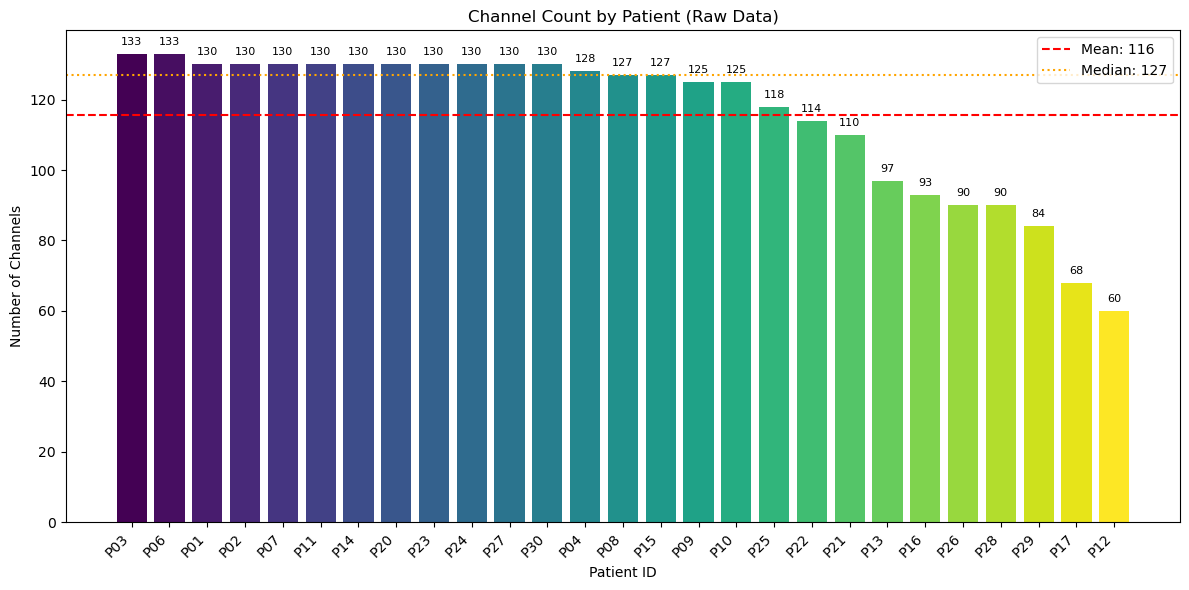


CHANNEL COUNTS BY PATIENT
Patient    Channels  
--------------------------------------------------
P03        133       
P06        133       
P01        130       
P02        130       
P07        130       
P11        130       
P14        130       
P20        130       
P23        130       
P24        130       
P27        130       
P30        130       
P04        128       
P08        127       
P15        127       
P09        125       
P10        125       
P25        118       
P22        114       
P21        110       
P13        97        
P16        93        
P26        90        
P28        90        
P29        84        
P17        68        
P12        60        
--------------------------------------------------
Mean       115.6     
Median     127.0     
Min        60        
Max        133       
CHANNEL ANALYSIS ACROSS PIPELINE STAGES

Patient: P01
----------------------------------------------------------------------

1. RAW DATA (word_segments_dict):
   EEG 

NameError: name 'RawPreprocessor' is not defined

In [23]:
# 1. Check raw channel counts for all patients
channel_counts = compare_channel_counts_all_patients(pipeline)

# 2. Check channels at different pipeline stages for one patient
check_pipeline_channels(pipeline, patient_id='P01')

# 3. After running RawPreprocessor steps, check selected channels
opt = RawPreprocessor(pipeline, patient_id='P01')
opt.step1_split_instances()
opt.step2_analyze_channels()
opt.step2_select_channels(method='high30_snr')

check_preprocessor_channels(opt)

# 4. Visualize selected vs all channels
visualize_selected_vs_all_channels(pipeline, opt)

In [27]:
def get_patient_channel_info(pipeline):
    """
    Extract channel information for all patients from the pipeline.
    
    Args:
        pipeline: Dutch30Pipeline with loaded data
        
    Returns:
        Dict with channel info per patient
    """
    word_segments_dict = pipeline.split_result['word_segments_dict']
    
    channel_info = {}
    
    for pid in word_segments_dict.keys():
        patient_data = word_segments_dict[pid]
        words_data = patient_data['words']
        
        # Get channel count from first word instance
        first_word = list(words_data.keys())[0]
        eeg_segment = words_data[first_word]['instances'][0]['eeg_segment']
        
        # Count total instances
        total_instances = sum(len(w['instances']) for w in words_data.values())
        
        channel_info[pid] = {
            'n_channels': eeg_segment.shape[1],
            'n_words': len(words_data),
            'n_instances': total_instances,
            'eeg_samples_per_instance': eeg_segment.shape[0],
            'has_baseline': 'baseline' in patient_data,
        }
    
    return channel_info


def print_channel_summary(pipeline):
    """
    Print a summary table of channel info for all patients.
    """
    channel_info = get_patient_channel_info(pipeline)
    
    print("="*80)
    print("CHANNEL SUMMARY BY PATIENT")
    print("="*80)
    print(f"{'Patient':<10} {'Channels':<10} {'Words':<10} {'Instances':<12} {'Samples/Inst':<15} {'Baseline':<10}")
    print("-"*80)
    
    # Sort by patient ID
    for pid in sorted(channel_info.keys()):
        info = channel_info[pid]
        print(f"{pid:<10} {info['n_channels']:<10} {info['n_words']:<10} "
              f"{info['n_instances']:<12} {info['eeg_samples_per_instance']:<15} "
              f"{'Yes' if info['has_baseline'] else 'No':<10}")
    
    # Summary stats
    n_channels_list = [info['n_channels'] for info in channel_info.values()]
    print("-"*80)
    print(f"{'TOTAL':<10} {'':<10} {'':<10} {'':<12} {'':<15}")
    print(f"{'Min':<10} {min(n_channels_list):<10}")
    print(f"{'Max':<10} {max(n_channels_list):<10}")
    print(f"{'Mean':<10} {sum(n_channels_list)/len(n_channels_list):<10.1f}")
    
    return channel_info


def visualize_patient_signals(pipeline, patient_ids=None, duration_sec=1.0, n_channels_to_show=20,
                              preprocessor_dict=None, show_selected=False):
    """
    Visualize raw EEG signals for each patient.
    
    Args:
        pipeline: Pipeline with loaded data
        patient_ids: List of patient IDs (default: all available)
        duration_sec: Duration of signal to show in seconds
        n_channels_to_show: Number of channels to display per patient
        preprocessor_dict: Dict of {patient_id: RawPreprocessor} with channel selection
        show_selected: If True and preprocessor_dict provided, show only selected channels
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    word_segments_dict = pipeline.split_result['word_segments_dict']
    config = pipeline.config
    
    if patient_ids is None:
        patient_ids = list(word_segments_dict.keys())
    
    n_patients = len(patient_ids)
    n_cols = min(3, n_patients)
    n_rows = (n_patients + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
    if n_patients == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    patient_stats = {}
    
    for idx, pid in enumerate(patient_ids):
        ax = axes[idx]
        
        if pid not in word_segments_dict:
            ax.set_title(f"{pid}: No data")
            continue
        
        # Get first word's EEG segment
        words_data = word_segments_dict[pid]['words']
        first_word = list(words_data.keys())[0]
        eeg_segment = words_data[first_word]['instances'][0]['eeg_segment']
        
        n_samples = min(int(duration_sec * config.eeg_sr), eeg_segment.shape[0])
        n_channels_total = eeg_segment.shape[1]
        
        # Determine which channels to plot
        if show_selected and preprocessor_dict and pid in preprocessor_dict:
            opt = preprocessor_dict[pid]
            if hasattr(opt, 'selected_channels') and opt.selected_channels is not None:
                available_channels = opt.selected_channels
                selection_method = opt.channel_selection_method
            else:
                available_channels = list(range(n_channels_total))
                selection_method = "none"
        else:
            available_channels = list(range(n_channels_total))
            selection_method = "all"
        
        n_available = len(available_channels)
        channels_to_plot = min(n_channels_to_show, n_available)
        
        # Select evenly spaced channels
        plot_indices = np.linspace(0, n_available-1, channels_to_plot, dtype=int)
        channel_indices = [available_channels[i] for i in plot_indices]
        
        # Time axis
        time = np.arange(n_samples) / config.eeg_sr * 1000
        
        # Get EEG subset
        eeg_subset = eeg_segment[:n_samples, channel_indices]
        
        # Normalize for visualization
        eeg_norm = eeg_subset / (np.std(eeg_subset) + 1e-10)
        
        # Add offset for each channel
        offsets = np.arange(channels_to_plot) * 4
        eeg_offset = eeg_norm + offsets
        
        # Plot
        color = 'green' if show_selected else 'blue'
        for ch_idx in range(channels_to_plot):
            ax.plot(time, eeg_offset[:, ch_idx], linewidth=0.5, alpha=0.8, color=color)
        
        # Calculate stats
        eeg_for_stats = eeg_segment[:, available_channels]
        signal_std = np.std(eeg_for_stats)
        signal_range = np.ptp(eeg_for_stats)
        
        patient_stats[pid] = {
            'n_channels_total': n_channels_total,
            'n_channels_used': n_available,
            'selection_method': selection_method,
            'std': signal_std,
            'range': signal_range,
        }
        
        title = f"{pid}: {n_available}/{n_channels_total} ch"
        if selection_method != "all":
            title += f" ({selection_method})"
        title += f"\nstd={signal_std:.1f}"
        
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Time (ms)")
        ax.set_ylabel("Channels")
        ax.set_xlim([0, time[-1]])
    
    # Hide unused axes
    for idx in range(n_patients, len(axes)):
        axes[idx].set_visible(False)
    
    mode_str = "Selected Channels" if show_selected else "All Channels"
    plt.suptitle(f"EEG Signals by Patient ({mode_str})", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n" + "="*90)
    print(f"SIGNAL STATISTICS ({mode_str})")
    print("="*90)
    print(f"{'Patient':<10} {'Total':<8} {'Used':<8} {'Method':<15} {'Std':<12} {'Range':<12}")
    print("-"*90)
    
    for pid in sorted(patient_stats.keys()):
        s = patient_stats[pid]
        print(f"{pid:<10} {s['n_channels_total']:<8} {s['n_channels_used']:<8} "
              f"{s['selection_method']:<15} {s['std']:<12.2f} {s['range']:<12.2f}")
    
    return patient_stats


def visualize_channel_distributions(pipeline, patient_ids=None, preprocessor_dict=None):
    """
    Show distribution of signal amplitude across channels, highlighting selected channels.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    word_segments_dict = pipeline.split_result['word_segments_dict']
    
    if patient_ids is None:
        patient_ids = list(word_segments_dict.keys())[:6]
    
    n_patients = len(patient_ids)
    fig, axes = plt.subplots(2, n_patients, figsize=(4*n_patients, 8))
    
    if n_patients == 1:
        axes = axes.reshape(2, 1)
    
    for idx, pid in enumerate(patient_ids):
        if pid not in word_segments_dict:
            continue
        
        # Collect EEG from multiple words
        words_data = word_segments_dict[pid]['words']
        all_eeg = []
        
        for word, word_info in list(words_data.items())[:20]:
            for instance in word_info['instances'][:3]:
                eeg = instance['eeg_segment']
                all_eeg.append(eeg)
        
        if not all_eeg:
            continue
        
        eeg_concat = np.vstack(all_eeg)
        n_channels = eeg_concat.shape[1]
        
        # Get selected channels if available
        selected_channels = None
        selection_method = "none"
        if preprocessor_dict and pid in preprocessor_dict:
            opt = preprocessor_dict[pid]
            if hasattr(opt, 'selected_channels') and opt.selected_channels is not None:
                selected_channels = set(opt.selected_channels)
                selection_method = opt.channel_selection_method
        
        # Calculate per-channel statistics
        channel_std = np.std(eeg_concat, axis=0)
        median_std = np.median(channel_std)
        outlier_threshold = median_std * 3
        
        # Top plot: All channels with selection highlighted
        ax1 = axes[0, idx]
        
        if selected_channels is not None:
            colors = ['green' if i in selected_channels else 'lightgray' for i in range(n_channels)]
        else:
            colors = ['blue'] * n_channels
        
        ax1.bar(range(n_channels), channel_std, color=colors, alpha=0.7, width=1.0)
        ax1.axhline(median_std, color='r', linestyle='--', linewidth=1, label='median')
        ax1.axhline(outlier_threshold, color='orange', linestyle=':', linewidth=1, label='3x median')
        
        n_selected = len(selected_channels) if selected_channels else n_channels
        ax1.set_title(f"{pid}: {n_selected}/{n_channels} ch\n({selection_method})", fontsize=10)
        ax1.set_xlabel("Channel Index")
        ax1.set_ylabel("Std Dev")
        if idx == 0:
            ax1.legend(fontsize=7, loc='upper right')
        
        # Bottom plot: Outlier analysis
        ax2 = axes[1, idx]
        
        colors = []
        for i, s in enumerate(channel_std):
            is_outlier = s > outlier_threshold
            is_selected = selected_channels is not None and i in selected_channels
            
            if is_outlier and is_selected:
                colors.append('orange')
            elif is_outlier:
                colors.append('red')
            elif is_selected:
                colors.append('green')
            elif selected_channels is not None:
                colors.append('lightgray')
            else:
                colors.append('blue')
        
        ax2.bar(range(n_channels), channel_std, color=colors, alpha=0.7, width=1.0)
        ax2.axhline(outlier_threshold, color='red', linestyle='--', linewidth=1)
        
        # Count stats
        n_outliers = sum(1 for s in channel_std if s > outlier_threshold)
        n_selected_outliers = 0
        if selected_channels:
            n_selected_outliers = sum(1 for i, s in enumerate(channel_std) 
                                      if s > outlier_threshold and i in selected_channels)
        
        ax2.set_title(f"Outliers: {n_outliers} total, {n_selected_outliers} in selection", fontsize=10)
        ax2.set_xlabel("Channel Index")
        ax2.set_ylabel("Std Dev")
    
    plt.suptitle("Channel Amplitude Distributions\n(green=selected, gray=excluded, red=outlier, orange=selected+outlier)", 
                fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


def visualize_signal_spectra(pipeline, patient_ids=None, preprocessor_dict=None, 
                             show_selected_only=False):
    """
    Show power spectral density for each patient.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.signal import welch
    
    word_segments_dict = pipeline.split_result['word_segments_dict']
    config = pipeline.config
    
    if patient_ids is None:
        patient_ids = list(word_segments_dict.keys())[:6]
    
    n_patients = len(patient_ids)
    fig, axes = plt.subplots(1, n_patients, figsize=(4*n_patients, 4))
    
    if n_patients == 1:
        axes = [axes]
    
    for idx, pid in enumerate(patient_ids):
        ax = axes[idx]
        
        if pid not in word_segments_dict:
            continue
        
        # Get EEG data
        words_data = word_segments_dict[pid]['words']
        all_eeg = []
        
        for word, word_info in list(words_data.items())[:10]:
            for instance in word_info['instances'][:2]:
                eeg = instance['eeg_segment']
                all_eeg.append(eeg)
        
        if not all_eeg:
            continue
        
        eeg_concat = np.vstack(all_eeg)
        n_channels_total = eeg_concat.shape[1]
        
        # Determine which channels to use
        if show_selected_only and preprocessor_dict and pid in preprocessor_dict:
            opt = preprocessor_dict[pid]
            if hasattr(opt, 'selected_channels') and opt.selected_channels is not None:
                channels_to_use = opt.selected_channels
                label = f"{len(channels_to_use)} selected"
            else:
                channels_to_use = list(range(n_channels_total))
                label = f"{n_channels_total} all"
        else:
            channels_to_use = list(range(min(30, n_channels_total)))
            label = f"{len(channels_to_use)} sampled"
        
        # Compute average PSD
        psds = []
        for ch in channels_to_use[:30]:
            freqs, psd = welch(eeg_concat[:, ch], fs=config.eeg_sr, nperseg=256)
            psds.append(psd)
        
        avg_psd = np.mean(psds, axis=0)
        
        # Plot
        ax.semilogy(freqs, avg_psd, linewidth=1)
        ax.axvline(70, color='g', linestyle='--', alpha=0.5)
        ax.axvline(170, color='r', linestyle='--', alpha=0.5)
        ax.axvspan(70, 170, alpha=0.1, color='green')
        
        ax.set_title(f"{pid} ({label})")
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Power")
        ax.set_xlim([0, 250])
    
    plt.suptitle("Power Spectral Density (High Gamma: 70-170 Hz shaded)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def build_preprocessor_dict(pipeline, patient_ids=None, channel_method='high30_snr'):
    """
    Build preprocessors with channel selection for multiple patients.
    
    Args:
        pipeline: Dutch30Pipeline
        patient_ids: List of patient IDs (default: all)
        channel_method: 'high30_snr', 'low30_kurt', 'all', or 'best'
        
    Returns:
        Dict of {patient_id: RawPreprocessor}
    """
    word_segments_dict = pipeline.split_result['word_segments_dict']
    
    if patient_ids is None:
        patient_ids = list(word_segments_dict.keys())
    
    preprocessor_dict = {}
    
    print(f"Building preprocessors for {len(patient_ids)} patients...")
    print("-"*60)
    
    for pid in patient_ids:
        try:
            opt = RawPreprocessor(pipeline, patient_id=pid)
            opt.step1_split_instances()
            opt.step2_analyze_channels()
            
            if channel_method == 'best':
                best_ch = max(opt.channel_analysis_results.keys(), 
                             key=lambda k: opt.channel_analysis_results[k]['val_acc'])
                opt.step2_select_channels(method=best_ch)
            elif channel_method == 'all':
                opt.selected_channels = list(range(opt.n_channels_total))
                opt.channel_selection_method = 'all'
            else:
                opt.step2_select_channels(method=channel_method)
            
            preprocessor_dict[pid] = opt
            print(f"  {pid}: {len(opt.selected_channels)}/{opt.n_channels_total} channels ({opt.channel_selection_method})")
            
        except Exception as e:
            print(f"  {pid}: FAILED - {e}")
    
    print("-"*60)
    print(f"Successfully processed: {len(preprocessor_dict)}/{len(patient_ids)} patients")
    
    return preprocessor_dict

CHANNEL SUMMARY BY PATIENT
Patient    Channels   Words      Instances    Samples/Inst    Baseline  
--------------------------------------------------------------------------------
P01        130        101        101          2047            Yes       
P02        130        101        101          2052            Yes       
P03        133        101        101          2052            Yes       
P04        128        101        101          2047            Yes       
P06        133        101        101          2046            Yes       
P07        130        101        101          2049            Yes       
P08        127        101        101          2054            Yes       
P09        125        100        100          2048            Yes       
P10        125        96         96           2046            Yes       
P11        130        20         100          2058            Yes       
P12        60         20         100          2056            Yes       
P13        97   

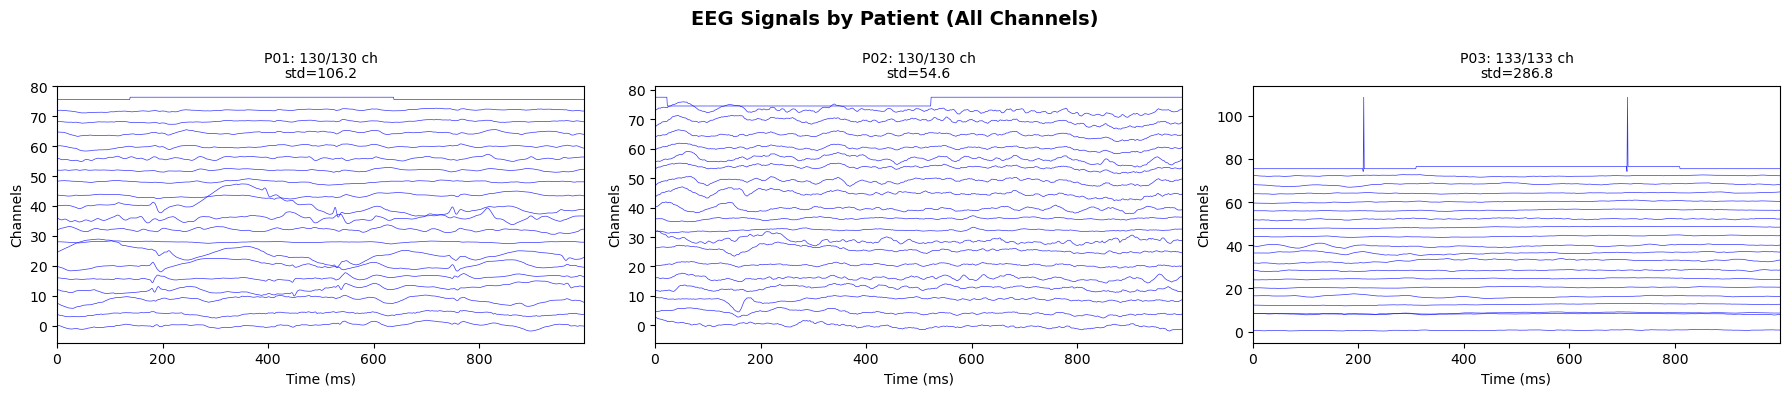


SIGNAL STATISTICS (All Channels)
Patient    Total    Used     Method          Std          Range       
------------------------------------------------------------------------------------------
P01        130      130      all             106.23       2503.42     
P02        130      130      all             54.60        3851.56     
P03        133      133      all             286.82       6399.90     

=== SELECTED CHANNELS ===


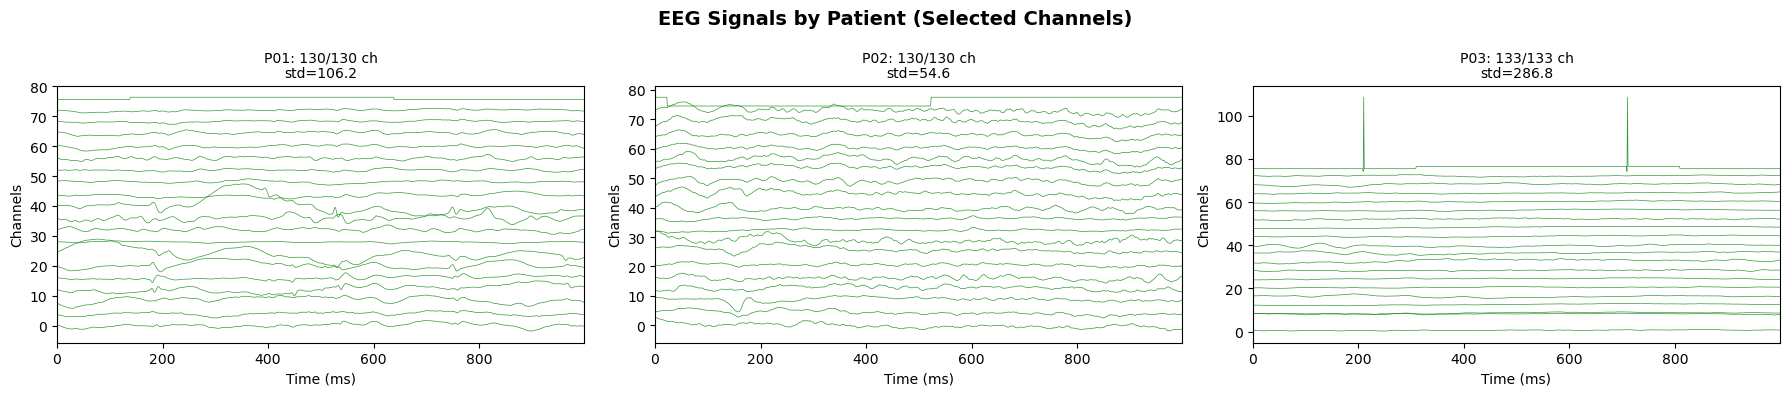


SIGNAL STATISTICS (Selected Channels)
Patient    Total    Used     Method          Std          Range       
------------------------------------------------------------------------------------------
P01        130      130      all             106.23       2503.42     
P02        130      130      all             54.60        3851.56     
P03        133      133      all             286.82       6399.90     


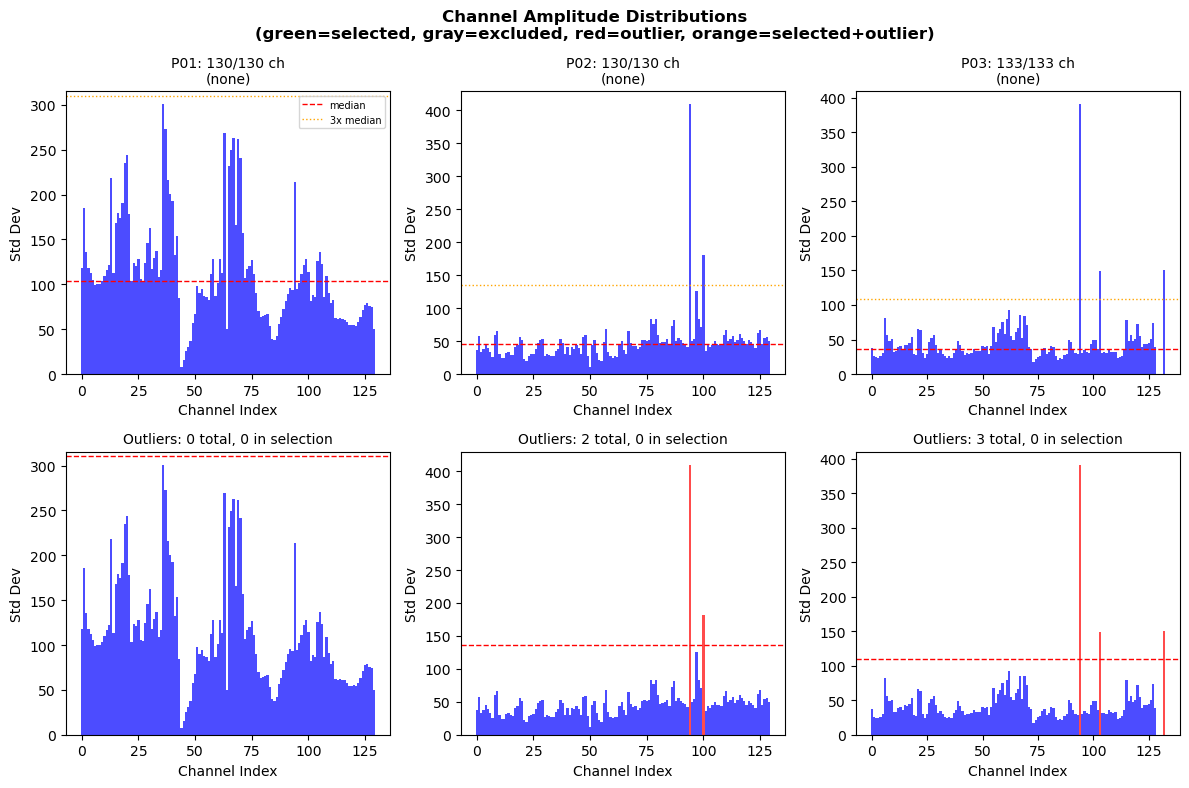

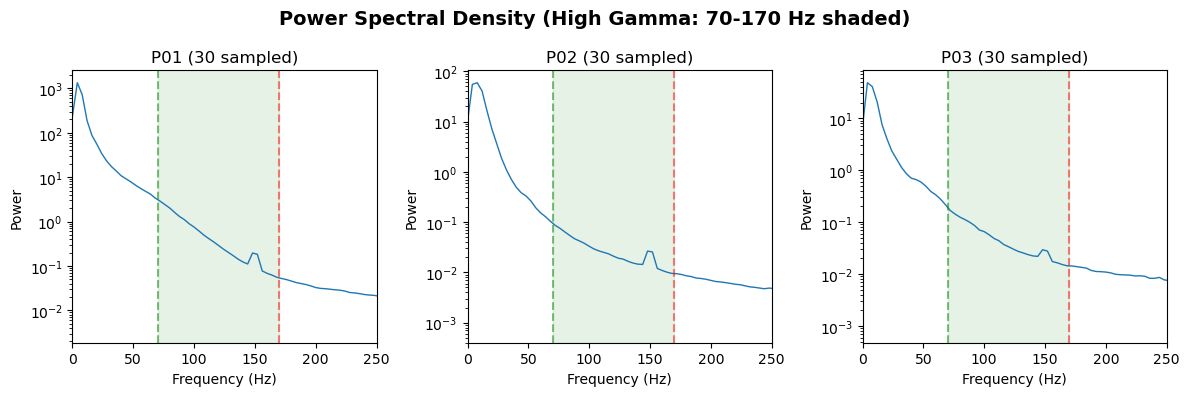

In [29]:
# 1. Get channel summary for all patients
channel_info = print_channel_summary(pipeline)

# 2. Build preprocessors with channel selection
preprocessor_dict = build_preprocessor_dict(
    pipeline, 
    patient_ids=['P01', 'P02', 'P03', 'P05', 'P06', 'P07'],
    channel_method='high30_snr'  # or 'best', 'all', 'low30_kurt'
)

# 3. Visualize ALL channels
print("\n=== ALL CHANNELS ===")
visualize_patient_signals(
    pipeline, 
    patient_ids=['P01', 'P02', 'P03'],
    show_selected=False
)

# 4. Visualize SELECTED channels only
print("\n=== SELECTED CHANNELS ===")
visualize_patient_signals(
    pipeline, 
    patient_ids=['P01', 'P02', 'P03'],
    preprocessor_dict=preprocessor_dict,
    show_selected=True
)

# 5. Channel distributions with selection highlighted
visualize_channel_distributions(
    pipeline,
    patient_ids=['P01', 'P02', 'P03'],
    preprocessor_dict=preprocessor_dict
)

# 6. Power spectra for selected channels
visualize_signal_spectra(
    pipeline,
    patient_ids=['P01', 'P02', 'P03'],
    preprocessor_dict=preprocessor_dict,
    show_selected_only=True
)